## Setup

In [2]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [3]:
from pathlib import Path
import pandas as pd
import geopandas as gpd
import shapely

import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# import kml reading and set supported driver
import fiona

fiona.drvsupport.supported_drivers["KML"] = "rw"

# for parsing HTML inside the Description field
from bs4 import BeautifulSoup

In [4]:
from gridsample.utils import save_shapefiles

In [5]:
INDIA_PROJECTED_CRS = "24378"

In [6]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
PROCESSED_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks"  # / "01 Cleaned Khasras"

In [7]:
# Function to add suffix only to duplicates (leave unique values unchanged)
def add_suffix_to_duplicates(series):
    counts = {}
    value_counts = series.value_counts()
    result = []
    for item in series:
        if value_counts[item] > 1:
            counts[item] = counts.get(item, 0) + 1
            result.append(f"{item} (Part {counts[item]})")
        else:
            result.append(item)
    return result

In [8]:
# Parse description variables


def description_parser_single_row(html_content):
    # Parse the HTML content
    soup = BeautifulSoup(html_content, "html.parser")

    # Find the inner table containing the attributes
    inner_table = soup.find_all("table")[1]

    # Extract rows from the inner table
    rows = inner_table.find_all("tr")

    # Create a dictionary to store attributes and their values
    data = {}
    for row in rows:
        cols = row.find_all("td")
        if len(cols) == 2:
            key = cols[0].text.strip()
            value = cols[1].text.strip()
            data[key] = value

    return pd.DataFrame([data])


def description_parser(df, description_col_name="Description"):
    # make dataframe of variables
    data = [
        description_parser_single_row(df[description_col_name].values[i])
        for i in range(len(df))
    ]
    df_vars = pd.concat(data)
    df_vars.set_index(df.index, inplace=True)

    return df_vars

## Load raw shapes and process

### Dhar

In [8]:
# Load dhar khasras
raw_dhar_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Dhar Khasras" / "doc.kml", driver="KML"
)

In [9]:
# remove z-dimension
raw_dhar_gdf.geometry = raw_dhar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons and only keep the polygon
raw_dhar_gdf = raw_dhar_gdf.explode(index_parts=False)
raw_dhar_gdf = raw_dhar_gdf[raw_dhar_gdf.geometry.type == "Polygon"]

# remove useless Description column
dhar_gdf = raw_dhar_gdf.drop(columns="Description")

In [10]:
# drop large green shapes (open .KMZ on Google Earth to see)
dhar_gdf = dhar_gdf[dhar_gdf["Name"] != ""]

In [11]:
# clean up Name so we can separate the villages (string names) from the areas (numbers only)
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["Name"].str.split("/")
]
dhar_gdf["cleaned_name"] = [
    value[0].strip() for value in dhar_gdf["cleaned_name"].str.split(",")
]

In [12]:
# manual clean
dhar_gdf.loc[dhar_gdf["Name"] == "2829Z1", "cleaned_name"] = "2829"

<Axes: >

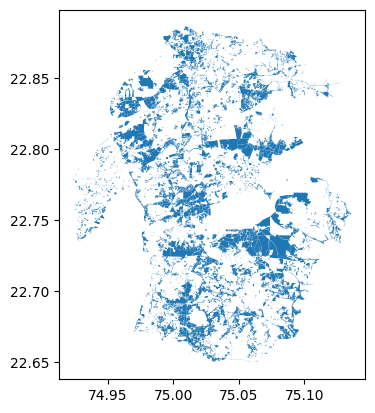

In [13]:
# ISOLATE AREA ONLY - select rows that have a number as their Name
dhar_yellow_shapes_gdf = dhar_gdf[dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_yellow_shapes_gdf.plot()

<Axes: >

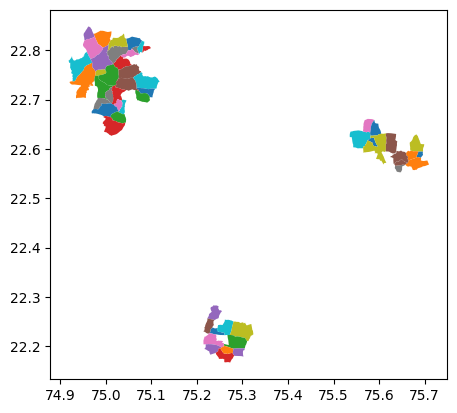

In [14]:
# ISOLATE VILLAGES ONLY - select rows that have a string as their Name
dhar_village_shapes_gdf = dhar_gdf[~dhar_gdf["cleaned_name"].str.isnumeric()]
dhar_village_shapes_gdf = dhar_village_shapes_gdf.drop(columns="cleaned_name")
dhar_village_shapes_gdf = dhar_village_shapes_gdf.rename(
    columns={"Name": "village_name"}
)
dhar_village_shapes_gdf.plot(column="village_name")

Missing village name: 2394
Has village name: 4905


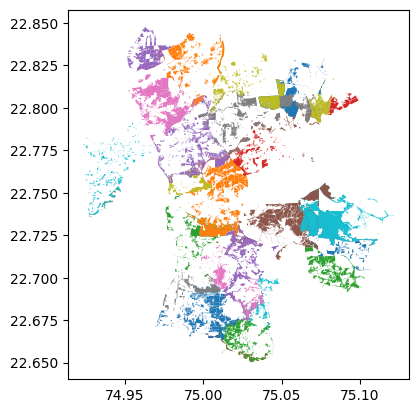

In [15]:
# add village names to areas
dhar_processed_areas_gdf = dhar_yellow_shapes_gdf.sjoin(
    dhar_village_shapes_gdf, how="left", predicate="intersects"
).drop(columns="index_right")
dhar_processed_areas_gdf.plot(column="village_name")
print("Missing village name:", dhar_processed_areas_gdf["village_name"].isnull().sum())
print("Has village name:", dhar_processed_areas_gdf["village_name"].notnull().sum())

In [16]:
# Apply the function to the khasra_id column
dhar_processed_areas_gdf["khasra_id"] = dhar_processed_areas_gdf["Name"]
dhar_processed_areas_gdf["khasra_id"] = add_suffix_to_duplicates(
    dhar_processed_areas_gdf["khasra_id"]
)

In [17]:
dhar_processed_areas_gdf.drop(columns="cleaned_name", inplace=True)

In [18]:
# save to file
save_shapefiles(
    dhar_processed_areas_gdf,
    PROCESSED_DATA_DIR / "Dhar" / "dhar_cleaned_khasras",
    "dhar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Sagar

In [19]:
gdfs = []

for filename in ["sagar_khamkuwa", "sagar_mokalpur", "sagar_tekapar"]:
    gdf = gpd.read_file(
        RAW_DATA_DIR / "solar_park_shapefiles" / "Sagar Khasras" / f"{filename}.kml",
        driver="KML",
    )
    gdf["source"] = filename
    gdfs.append(gdf)

raw_sagar_gdf = pd.concat(gdfs, ignore_index=True)

<Axes: >

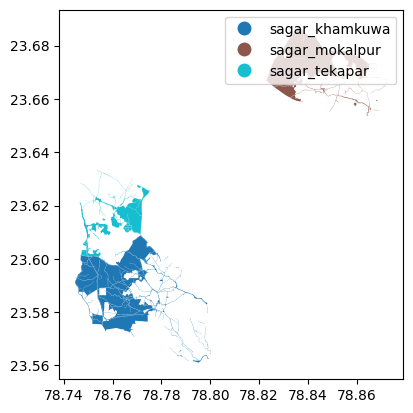

In [20]:
# remove z-dimension
raw_sagar_gdf.geometry = raw_sagar_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
raw_sagar_gdf = raw_sagar_gdf.explode(column="geometry", ignore_index=True)
raw_sagar_gdf.plot(column="source", legend=True)

In [21]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_sagar_gdf)
raw_sagar_gdf.drop(columns=["Name", "Description"], inplace=True)
sagar_gdf = raw_sagar_gdf.merge(df_vars, left_index=True, right_index=True)

<Axes: >

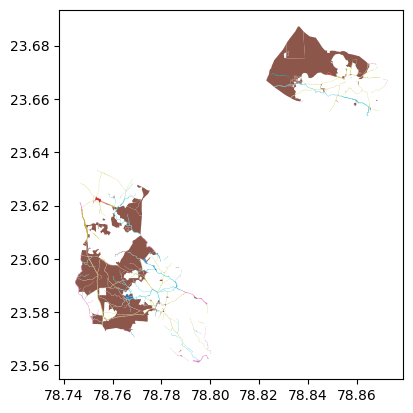

In [22]:
sagar_gdf.plot(column="PAR_TYPE")

In [23]:
sagar_gdf["village_name"] = sagar_gdf["source"].str.split("_").str[1]
sagar_gdf["source"] = sagar_gdf["source"].str.split("_").str[0]

In [24]:
# sagar_gdf["khasra_id"] = "SAGAR_" + sagar_gdf["UNQID"]
sagar_gdf["khasra_id"] = sagar_gdf["village_name"] + "_" + sagar_gdf["KID"]
sagar_gdf["khasra_id"] = add_suffix_to_duplicates(sagar_gdf["khasra_id"])

In [25]:
save_shapefiles(
    sagar_gdf,
    PROCESSED_DATA_DIR / "Sagar" / "sagar_cleaned_khasras",
    "sagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Ashok Nagar

In [26]:
gdf = gpd.read_file(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Ashok Nagar Khasras"
    / "Ashok_nagar_khasras.kml",
    driver="KML",
)

In [27]:
# remove z-dimension
gdf.geometry = gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [28]:
gdf

,Name,Description,geometry
0,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71443 24.38757, 77.71444 24..."
1,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71443 24.38757, 77.71407 24..."
2,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.72160 24.38990, 77.72142 24..."
3,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71978 24.38991, 77.71959 24..."
4,ASKN_7,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.71797 24.38994, 77.71754 24..."
...,...,...,...
342,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85647 24.70911, 77.85646 24..."
343,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85645 24.70830, 77.85648 24..."
344,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85743 24.70827, 77.85696 24..."
345,ASKN_49,"<html xmlns:fo=""http://www.w3.org/1999/XSL/For...","MULTIPOLYGON (((77.85831 24.70821, 77.85815 24..."


<Axes: >

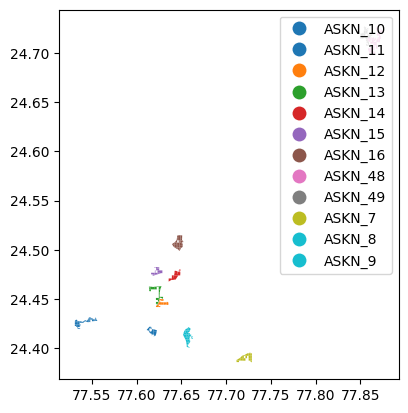

In [29]:
gdf.plot(column="Name", legend=True)

In [30]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(gdf)
gdf.drop(columns=["Name", "Description"], inplace=True)
gdf_merged = gdf.merge(df_vars, left_index=True, right_index=True)

In [31]:
gdf_merged.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
        "khasra_no": "Name",
        "Patch_Name": "parcel_id",
    },
    inplace=True,
)

In [32]:
save_shapefiles(
    gdf_merged,
    PROCESSED_DATA_DIR / "Ashok Nagar" / "ashok_nagar_cleaned_khasras",
    "ashok_nagar_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Shivpuri

In [33]:
raw_shivpuri_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Shivpuri Khasras" / "Shivpuri_khasra.kml",
    driver="KML",
)

In [34]:
# remove z-dimension
raw_shivpuri_gdf.geometry = raw_shivpuri_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons (each one just contains one polygon anyway)
# gdf = gdf.explode(column='geometry', ignore_index=True)

In [35]:
# parse Description variables and merge with shapes dataframe
df_vars = description_parser(raw_shivpuri_gdf)
raw_shivpuri_gdf.drop(columns=["Name", "Description"], inplace=True)
shivpuri_gdf = raw_shivpuri_gdf.merge(df_vars, left_index=True, right_index=True)

<Axes: >

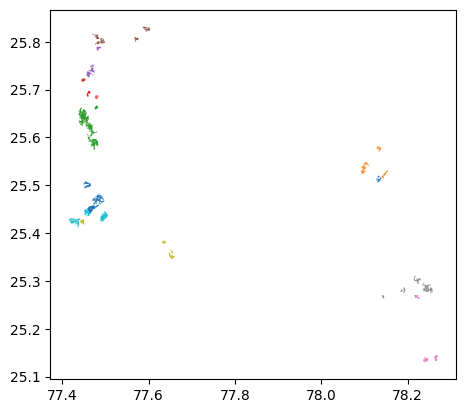

In [36]:
shivpuri_gdf.plot(column="Patch_Name")

<Axes: >

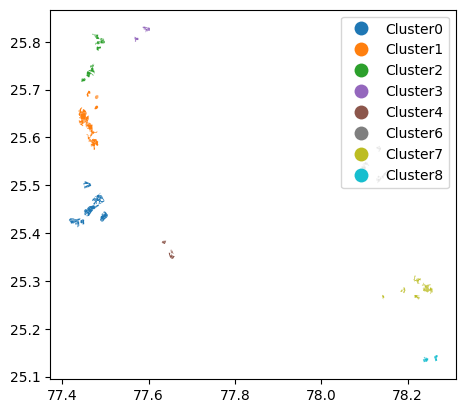

In [37]:
shivpuri_gdf.plot(column="Cluster", legend=True)

In [38]:
shivpuri_gdf

,geometry,FID,Area_ha,Patch_Name,districtc,tehsilcode,villageh,villagee,bhucode,khasra_no,...,ownername,column12in,noiyat,landtype,GIS_Area_h,teh_nm_e,ccode11,lgd_gp_cd,uid,Cluster
0,"MULTIPOLYGON (((78.23840 25.14023, 78.23810 25...",0,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2831,...,(शासकीय),,चारागाह 1.0000,शासकीय,1.033963,Pichhore,456248,151450,050603001001742831,Cluster8
1,"MULTIPOLYGON (((78.24014 25.14096, 78.23970 25...",1,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2832,...,(शासकीय),,चारागाह 3.5900,शासकीय,3.702107,Pichhore,456248,151450,050603001001742832,Cluster8
2,"MULTIPOLYGON (((78.24106 25.14042, 78.24111 25...",2,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2833,...,(शासकीय),,चारागाह 0.2300,शासकीय,0.248963,Pichhore,456248,151450,050603001001742833,Cluster8
3,"MULTIPOLYGON (((78.23943 25.13843, 78.23933 25...",3,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2836,...,(शासकीय),,चारागाह 0.9000,शासकीय,0.873786,Pichhore,456248,151450,050603001001742836,Cluster8
4,"MULTIPOLYGON (((78.23916 25.13742, 78.23912 25...",4,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2837,...,(शासकीय),,बंघीया 1.0500,शासकीय,0.038632,Pichhore,456248,151450,050603001001742837,Cluster8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
970,"MULTIPOLYGON (((77.47755 25.81260, 77.47613 25...",970,79.488672,SVPI_176,423,01009,ठेवला,Thewala,05090100002005,1154/2,...,(शासकीय),,0.8000पठार 0.8000 0.8000,शासकीय,0.90143,Bairrad,454991,151812,050901000020051154/2,Cluster2
971,"MULTIPOLYGON (((77.47682 25.81431, 77.47701 25...",971,79.488672,SVPI_176,423,01009,ठेवला,Thewala,05090100002005,1149/2,...,(शासकीय),,5.0000 5.0000 5.0000,शासकीय,1.768495,Bairrad,454991,151812,050901000020051149/2,Cluster2
972,"MULTIPOLYGON (((78.23841 25.13607, 78.23830 25...",972,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2855,...,(शासकीय),,पठार 0.1500,शासकीय,0.161368,Pichhore,456248,151450,050603001001742855,Cluster8
973,"MULTIPOLYGON (((78.23881 25.13629, 78.23886 25...",973,88.340255,SVPI_18,423,03413,कमालपुर,Kamalpur,05060300100174,2856,...,(शासकीय),,पठार 0.0400,शासकीय,0.055191,Pichhore,456248,151450,050603001001742856,Cluster8


In [39]:
shivpuri_gdf.columns

Index(['geometry', 'FID', 'Area_ha', 'Patch_Name', 'districtc', 'tehsilcode',
       'villageh', 'villagee', 'bhucode', 'khasra_no', 'khasra_are',
       'ownername', 'column12in', 'noiyat', 'landtype', 'GIS_Area_h',
       'teh_nm_e', 'ccode11', 'lgd_gp_cd', 'uid', 'Cluster'],
      dtype='object')

In [40]:
shivpuri_gdf.rename(
    columns={
        "villagee": "village_name",
        "uid": "khasra_id",
    },
    inplace=True,
)

In [41]:
save_shapefiles(
    shivpuri_gdf,
    PROCESSED_DATA_DIR / "Shivpuri" / "shivpuri_cleaned_khasras",
    "shivpuri_cleaned_khasras",
    formats=["kml", "parquet"],
)

### Morena

In [42]:
import re


def parse_morena_description_col_to_dict(desc):
    # Remove leading text before first <B> tag
    desc = re.sub(r"^.*?<B>", "<B>", desc, flags=re.DOTALL)
    # Find all <B>key</B> = value<BR> pairs
    matches = re.findall(r"<B>([^<]+)</B>\s*=\s*(.*?)<BR>", desc)
    # Build dictionary
    result = {k.strip(): v.strip() for k, v in matches}

    return result


def get_morena_description_as_df(description_series: pd.Series) -> pd.DataFrame:
    # Apply the function to the Description column
    df_description_dict_list = description_series.apply(
        parse_morena_description_col_to_dict
    ).tolist()
    df_vars = pd.DataFrame(df_description_dict_list, index=description_series.index)

    return df_vars

#### Vijaypur sub-area

In [43]:
raw_vijaypur_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "vijaypur_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_vijaypur_gdf = raw_vijaypur_gdf[
    ~raw_vijaypur_gdf["Name"].str.contains("Vijaypur|SEO", case=False, na=False)
]
filtered_vijaypur_gdf["Source"] = "Vijaypur Khasras"
filtered_vijaypur_gdf["Tehsil Name"] = "Vijaypur"

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [44]:
# # OLD - pull patch name out of the description
# filtered_vijaypur_gdf["Patch Name"] = filtered_vijaypur_gdf["Description"].str.extract(
#     r"patch_name</B> = (.+?)<BR>"
# )

# apply the function to the Description column
vijaypur_desc_vars_df = get_morena_description_as_df(
    filtered_vijaypur_gdf["Description"]
)
filtered_vijaypur_gdf = filtered_vijaypur_gdf.merge(
    vijaypur_desc_vars_df, left_index=True, right_index=True
)
filtered_vijaypur_gdf.drop(columns="Description", inplace=True)

In [45]:
cols_to_keep = [
    "Name",
    "geometry",
    "Source",
    "patch_name",
    # "patch_area",
    # "ID",
    # "DISTRICTC",
    "Tehsil Name",
    "TEHSILCODE",
    # "LGDGPCODE",
    # "CCODE11",
    # "VILLAGEH",
    "VILLAGEE",
    "BHUCODE",
    # "KHASRA_NO",
    # "KHASRA_ARE",
    # "OWNERNAME",
    # "COLUMN12IN",
    "NOIYAT",
    # "LANDTYPE",
    # "FEATUREID",
    # "DIST_CD",
    "ROR_kid",
    # "ROR_AREA",
    # "UID_AREA",
    # "LGDCD",
]
cols_rename = {
    "Name": "Khasra ID",
    "patch_name": "Patch Name",
    "TEHSILCODE": "Tehsil Code",
    "VILLAGEE": "Village Name",
    "BHUCODE": "BHU Code",
    "NOIYAT": "Noiyat",
    "ROR_kid": "ROR KID",
}

filtered_vijaypur_gdf = filtered_vijaypur_gdf[cols_to_keep]
filtered_vijaypur_gdf.rename(columns=cols_rename, inplace=True)

In [46]:
filtered_vijaypur_gdf

,Khasra ID,geometry,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID
279,181,GEOMETRYCOLLECTION Z (POINT Z (77.43395 25.785...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.8360,181/1/1
280,182,GEOMETRYCOLLECTION Z (POINT Z (77.43394 25.786...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.2090,182/1
281,253,GEOMETRYCOLLECTION Z (POINT Z (77.43308 25.783...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.3140,253/मिन-2
282,254,GEOMETRYCOLLECTION Z (POINT Z (77.43238 25.783...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,कदीम 0.1880,254/मिन-1
283,255,GEOMETRYCOLLECTION Z (POINT Z (77.43158 25.783...,Vijaypur Khasras,SEO1643,Vijaypur,03380,Bechai,46020200008100,तलैया 0.7730,255
...,...,...,...,...,...,...,...,...,...,...
5609,290,GEOMETRYCOLLECTION Z (POINT Z (77.53975 25.954...,Vijaypur Khasras,SEO2499,Vijaypur,03380,Kamlapur,46020300041191,0.3340पत्थर 0.3340 0.3340,290
5610,230,GEOMETRYCOLLECTION Z (POINT Z (77.53975 25.954...,Vijaypur Khasras,SEO2499,Vijaypur,03380,Dongarpur (gaswani),46020300039195,0.5330 0.5330,230
5611,466,GEOMETRYCOLLECTION Z (POINT Z (77.31799 26.114...,Vijaypur Khasras,SEO3041,Vijaypur,03380,Garhi,46020100017151,0.1570 0.1570,466
5612,323,GEOMETRYCOLLECTION Z (POINT Z (77.31799 26.114...,Vijaypur Khasras,SEO3041,Vijaypur,03380,Itawai,46020100026155,0.1780पहाड 0.1780 0.1780,323


#### Joura sub-area

In [47]:
raw_joura_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Morena Khasras" / "joura_khasras.kml",
    driver="KML",
)

# only select rows that DONT have the word Jaura or "MRA" in the name value
filtered_joura_gdf = raw_joura_gdf[
    ~raw_joura_gdf["Name"].str.contains("Joura|MRA", case=False, na=False)
]
filtered_joura_gdf["Source"] = "Joura Khasras"
filtered_joura_gdf["Tehsil Name"] = "Joura"

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [48]:
# # OLD - pull patch name out of the description
# filtered_joura_gdf["Patch Name"] = filtered_joura_gdf["Description"].str.extract(
#     r"patch_name</B> = (.+?)<BR>"
# )

# apply the function to the Description column
joura_desc_vars_df = get_morena_description_as_df(filtered_joura_gdf["Description"])
filtered_joura_gdf = filtered_joura_gdf.merge(
    joura_desc_vars_df, left_index=True, right_index=True
)
filtered_joura_gdf.drop(columns="Description", inplace=True)

In [49]:
filtered_joura_gdf = filtered_joura_gdf[cols_to_keep]
filtered_joura_gdf.rename(columns=cols_rename, inplace=True)

In [50]:
filtered_joura_gdf

,Khasra ID,geometry,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID
307,104,GEOMETRYCOLLECTION Z (POINT Z (77.55327 25.905...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,5.0170पहाड 5.0170 5.0170,104
308,106,GEOMETRYCOLLECTION Z (POINT Z (77.55318 25.909...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.9200पहाड 3.9200 3.9200,106
309,99,GEOMETRYCOLLECTION Z (POINT Z (77.55782 25.907...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,99
310,101,GEOMETRYCOLLECTION Z (POINT Z (77.55612 25.907...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,101
311,103,GEOMETRYCOLLECTION Z (POINT Z (77.55435 25.907...,Joura Khasras,MRA2,Joura,03388,Kushmani,01030800135251,3.3440पहाड 3.3440 3.3440,103
...,...,...,...,...,...,...,...,...,...,...
3900,826,GEOMETRYCOLLECTION Z (POINT Z (77.69922 26.467...,Joura Khasras,MRA2032,Joura,03388,Tajpur,01030200027032,गोत 0.2090 0.2090 0.2090,826
3901,211,GEOMETRYCOLLECTION Z (POINT Z (77.69665 26.464...,Joura Khasras,MRA2032,Joura,03388,Uttampura,01030200026030,कदीम अलाटमेंन्ट 0.2720 0.2720 0.2720,211/1
3902,264,GEOMETRYCOLLECTION Z (POINT Z (77.69665 26.464...,Joura Khasras,MRA2032,Joura,03388,Uttampura,01030200026030,कदीम 0.3660 0.3660 0.3660,264/5
3903,175,GEOMETRYCOLLECTION Z (POINT Z (77.69865 26.481...,Joura Khasras,MRA2089,Joura,03388,Uttampura,01030200026030,चारागाह 2.4040 2.4040 2.4040,175/2


#### Solar park boundary

In [51]:
raw_solar_park_boundary_gdf = gpd.read_file(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "solar_park_boundary.kml",
    driver="KML",
)
raw_solar_park_boundary_gdf["Source"] = "Solar Park Boundary"

In [52]:
# find <td>FID</td> <td>10</td> and store the value in "Patch Name" variable
raw_solar_park_boundary_gdf["Village Name"] = raw_solar_park_boundary_gdf[
    "Description"
].str.extract(r"<td>FID</td>\s*<td>(\d+)</td>")
raw_solar_park_boundary_gdf["Patch Name"] = raw_solar_park_boundary_gdf["Village Name"]
raw_solar_park_boundary_gdf.drop(columns="Description", inplace=True)

In [53]:
raw_solar_park_boundary_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)

#### Combine and clean

In [54]:
# combine into one gdf
morena_gdf = pd.concat(
    [
        filtered_joura_gdf,
        filtered_vijaypur_gdf,
        raw_solar_park_boundary_gdf,
    ],
    ignore_index=True,
)

In [55]:
morena_gdf.shape

(8944, 10)

<Axes: >

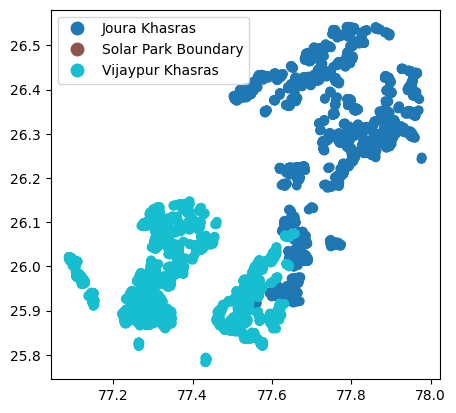

In [56]:
morena_gdf.plot(column="Source", legend=True)

In [57]:
# remove z-dimension
morena_gdf.geometry = morena_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
morena_gdf_clean = morena_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
morena_gdf_clean = morena_gdf_clean[
    morena_gdf_clean.geometry.type.isin(["Polygon", "MultiPolygon"])
]

In [58]:
len(morena_gdf_clean) == len(morena_gdf)

True

In [59]:
morena_gdf_clean = morena_gdf_clean.drop_duplicates(subset=["geometry"])
morena_gdf_clean.shape

(8447, 10)

In [60]:
morena_gdf_clean["Khasra ID (Unique)"] = (
    morena_gdf_clean["Khasra ID"].astype(str)
    + " ("
    + morena_gdf_clean["Village Name"].astype(str)
    + ")"
)

In [61]:
morena_gdf_clean["Khasra ID (Unique)"].nunique()

7568

In [62]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = morena_gdf_clean[
    morena_gdf_clean["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))
for khasra_id in tqdm(duplicated_khasraID_list):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        DATA_DIR
        / "01_processed"
        / "Solar Parks"
        / "Morena 2"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

Number of duplicated Khasra IDs: 471


  0%|          | 0/471 [00:00<?, ?it/s]

Ok, so it seems like these are khasra fragments. Merge them into one khasra, combining their shapes.

In [63]:
morena_gdf_dissolved = morena_gdf_clean.dissolve(by="Khasra ID (Unique)").reset_index()

# alternatively, add a suffix to get each fragment separately
# morena_gdf_clean["Khasra ID (Unique)"] = add_suffix_to_duplicates(morena_gdf_clean["Khasra ID (Unique)"])

#### Load Noiyat allocations and match

In [64]:
joura_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "Noiyat Files"
    / "teshil_joura_5HA_patch_identity.xlsx",
    sheet_name="identity_category",
)

vijaypur_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Morena Khasras"
    / "Noiyat Files"
    / "Vijaypur_5ha_Identity&Patch.xlsx",
    sheet_name="Sheopur_Identity_Category",
)
vijaypur_lookup.rename(
    columns={"category": "Category"},
    inplace=True,
)

In [65]:
barwani_khasra_gdf_dissolved = pd.concat(
    [joura_lookup, vijaypur_lookup], ignore_index=True
)
barwani_khasra_gdf_dissolved = barwani_khasra_gdf_dissolved.sort_values(
    by=["villagee", "kid_geometry"]
)
barwani_khasra_gdf_dissolved["Category"] = barwani_khasra_gdf_dissolved[
    "Category"
].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
barwani_khasra_gdf_dissolved["Khasra ID (Unique)"] = (
    barwani_khasra_gdf_dissolved["kid_geometry"].astype(str)
    + " ("
    + barwani_khasra_gdf_dissolved["villagee"].astype(str)
    + ")"
)

In [66]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = barwani_khasra_gdf_dissolved.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

Category,Khasra ID (Unique),Noiyat Unusable Area (ha)
0,1 (Andhupura),0.00
1,1 (Bara kalan),0.00
2,1 (Barhana),0.00
3,1 (Barkheda),13.65
4,1 (Bharkhoh),0.00
...,...,...
6632,998 (Lahosghani),0.33
6633,998 (Parsota),0.00
6634,999 (Deori),0.00
6635,999 (Khaneta),0.00


In [67]:
morena_gdf_merged = morena_gdf_dissolved.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
morena_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

morena_gdf_merged

,Khasra ID (Unique),geometry,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,Noiyat Unusable Area (ha)
0,1 (Andhupura),"POLYGON ((77.36208 26.11041, 77.36232 26.11075...",1,Vijaypur Khasras,SEO3049,Vijaypur,03380,Andhupura,46020100028160,16.4900पहाड 16.4900 16.4900,1,0.00
1,1 (Bara kalan),"POLYGON ((77.38585 26.13209, 77.38552 26.13196...",1,Vijaypur Khasras,SEO3130,Vijaypur,03380,Bara kalan,46020100031169,3.8140पहाड 3.8140 3.8140,1,0.00
2,1 (Barhana),"POLYGON ((77.79261 26.52551, 77.79241 26.52558...",1,Joura Khasras,MRA2233,Joura,03388,Barhana,01030600090137,चारागाह 3.9000,1,0.00
3,1 (Barkheda),"POLYGON ((77.34230 26.04357, 77.34205 26.04380...",1,Vijaypur Khasras,SEO2789,Vijaypur,03380,Barkheda,46020100021145,4.5500पठार 4.5500 4.5500,1/मिन-1,13.65
4,1 (Bharkhoh),"POLYGON ((77.34889 26.11283, 77.34888 26.11286...",1,Vijaypur Khasras,SEO3047,Vijaypur,03380,Bharkhoh,46020100026158,1.3500पहाड 1.3500 1.3500,1,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
7563,Unit III (0),"POLYGON ((77.65337 25.96200, 77.65306 25.96213...",Unit III,Solar Park Boundary,0,None,None,0,None,None,None,0.00
7564,Unit III (1),"POLYGON ((77.67168 25.95088, 77.67173 25.95193...",Unit III,Solar Park Boundary,1,None,None,1,None,None,None,0.00
7565,Unit III (5),"POLYGON ((77.66333 25.96044, 77.66289 25.96047...",Unit III,Solar Park Boundary,5,None,None,5,None,None,None,0.00
7566,Unit III (6),"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III,Solar Park Boundary,6,None,None,6,None,None,None,0.00


In [68]:
# Calculate original areas
morena_gdf_merged["Original Area (ha)"] = (
    morena_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [69]:
# add % unusable area
morena_gdf_merged["Noiyat Unusable Area (%)"] = (
    morena_gdf_merged["Noiyat Unusable Area (ha)"]
    / morena_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
morena_gdf_merged["Noiyat Unusable Area (%)"] = morena_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

<Axes: >

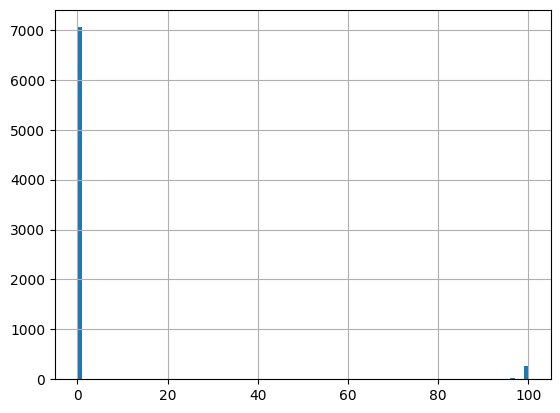

In [70]:
morena_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

In [71]:
# morena_gdf_merged[(morena_gdf_merged["Noiyat % Unusable Area"] > 80) & (morena_gdf_merged["Noiyat % Unusable Area"] < 100)]
morena_gdf_merged

,Khasra ID (Unique),geometry,Khasra ID,Source,Patch Name,Tehsil Name,Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID,Noiyat Unusable Area (ha),Original Area (ha),Noiyat Unusable Area (%)
0,1 (Andhupura),"POLYGON ((77.36208 26.11041, 77.36232 26.11075...",1,Vijaypur Khasras,SEO3049,Vijaypur,03380,Andhupura,46020100028160,16.4900पहाड 16.4900 16.4900,1,0.00,13.460888,0.0
1,1 (Bara kalan),"POLYGON ((77.38585 26.13209, 77.38552 26.13196...",1,Vijaypur Khasras,SEO3130,Vijaypur,03380,Bara kalan,46020100031169,3.8140पहाड 3.8140 3.8140,1,0.00,3.193237,0.0
2,1 (Barhana),"POLYGON ((77.79261 26.52551, 77.79241 26.52558...",1,Joura Khasras,MRA2233,Joura,03388,Barhana,01030600090137,चारागाह 3.9000,1,0.00,4.710804,0.0
3,1 (Barkheda),"POLYGON ((77.34230 26.04357, 77.34205 26.04380...",1,Vijaypur Khasras,SEO2789,Vijaypur,03380,Barkheda,46020100021145,4.5500पठार 4.5500 4.5500,1/मिन-1,13.65,4.338877,100.0
4,1 (Bharkhoh),"POLYGON ((77.34889 26.11283, 77.34888 26.11286...",1,Vijaypur Khasras,SEO3047,Vijaypur,03380,Bharkhoh,46020100026158,1.3500पहाड 1.3500 1.3500,1,0.00,1.279301,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7563,Unit III (0),"POLYGON ((77.65337 25.96200, 77.65306 25.96213...",Unit III,Solar Park Boundary,0,None,None,0,None,None,None,0.00,11.383233,0.0
7564,Unit III (1),"POLYGON ((77.67168 25.95088, 77.67173 25.95193...",Unit III,Solar Park Boundary,1,None,None,1,None,None,None,0.00,227.179405,0.0
7565,Unit III (5),"POLYGON ((77.66333 25.96044, 77.66289 25.96047...",Unit III,Solar Park Boundary,5,None,None,5,None,None,None,0.00,212.248952,0.0
7566,Unit III (6),"POLYGON ((77.65554 25.95982, 77.65599 25.96035...",Unit III,Solar Park Boundary,6,None,None,6,None,None,None,0.00,5.831037,0.0


In [72]:
save_shapefiles(
    morena_gdf_merged,
    DATA_DIR
    / "01_processed"
    / "Solar Parks"
    / "Morena 2"
    / "01 Processed Data"
    / "Cleaned Khasras",
    "morena_cleaned_khasras",
    formats=["kml", "parquet", "csv"],
)

### Barwani

In [106]:
barwani_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Barwani Khasras" / "barwani_khasras.kml",
    driver="KML",
)

In [107]:
# remove z-dimension
barwani_gdf.geometry = barwani_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
barwani_gdf = barwani_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
barwani_gdf = barwani_gdf[barwani_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

<Axes: >

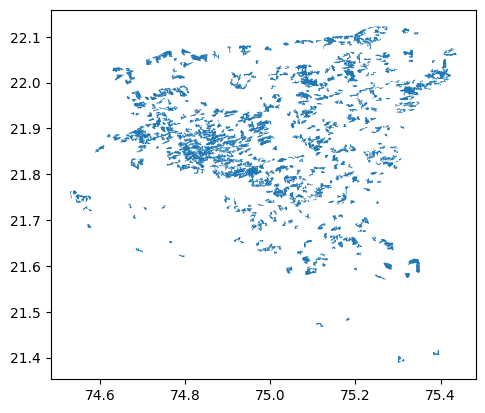

In [108]:
barwani_gdf.plot()

In [109]:
barwani_gdf

,Name,Description,geometry
1,"BWI20,21.382ha",Unknown Area Type,"POLYGON ((75.31239 21.39676, 75.31226 21.39676..."
3,"BWI32,66.778ha",Unknown Area Type,"POLYGON ((75.30071 21.40263, 75.30049 21.40264..."
5,"BWI48,37.171ha",Unknown Area Type,"POLYGON ((75.38583 21.41054, 75.38584 21.41073..."
7,"BWI52,33.242ha",Unknown Area Type,"POLYGON ((75.39581 21.41594, 75.39574 21.41609..."
9,"BWI99,49.073ha",Unknown Area Type,"POLYGON ((75.11652 21.47571, 75.11656 21.47571..."
...,...,...,...
32755,79/2,Unknown Area Type,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32757,38,Unknown Area Type,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32759,162,Unknown Area Type,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."
32761,120,Unknown Area Type,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."


In [110]:
# no info in Description
barwani_gdf.drop(columns=["Description"], inplace=True)

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [111]:
# the Name column has names like BWI20,21.382ha for patches and others are khasras
# separate those who start with BWI
barwani_patches_gdf = barwani_gdf[barwani_gdf["Name"].str.startswith("BWI")]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(",").str[0]
barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
barwani_patches_gdf

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_84427/2372441558.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)


,Patch Name,geometry
1,BWI20,"POLYGON ((75.31239 21.39676, 75.31226 21.39676..."
3,BWI32,"POLYGON ((75.30071 21.40263, 75.30049 21.40264..."
5,BWI48,"POLYGON ((75.38583 21.41054, 75.38584 21.41073..."
7,BWI52,"POLYGON ((75.39581 21.41594, 75.39574 21.41609..."
9,BWI99,"POLYGON ((75.11652 21.47571, 75.11656 21.47571..."
...,...,...
1273,BWI4548,"POLYGON ((75.32343 22.11060, 75.32340 22.11060..."
1275,BWI4550,"POLYGON ((75.25571 22.11138, 75.25571 22.11140..."
1277,BWI4553,"POLYGON ((75.24178 22.12154, 75.24160 22.12154..."
1279,BWI4556,"POLYGON ((75.25516 22.12228, 75.25468 22.12221..."


In [112]:
# khasras
barwani_khasra_gdf = barwani_gdf[~barwani_gdf["Name"].str.startswith("BWI")]
barwani_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
barwani_khasra_gdf

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_84427/463893839.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barwani_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)


,Khasra ID,geometry
1283,61,"POLYGON ((75.31456 21.39287, 75.31459 21.39299..."
1285,62,"POLYGON ((75.31456 21.39287, 75.31446 21.39290..."
1287,57,"POLYGON ((75.31134 21.39444, 75.31118 21.39443..."
1289,50,"POLYGON ((75.30451 21.39008, 75.30577 21.39097..."
1291,48,"POLYGON ((75.30416 21.39163, 75.30413 21.39163..."
...,...,...
32755,79/2,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32757,38,"POLYGON ((74.95441 22.01890, 74.95442 22.01897..."
32759,162,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."
32761,120,"POLYGON ((75.08386 22.00594, 75.08385 22.00594..."


In [113]:
len(barwani_khasra_gdf) + len(barwani_patches_gdf) == len(barwani_gdf)

True

In [114]:
barwani_khasra_gdf = barwani_khasra_gdf.sjoin(
    barwani_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
barwani_khasra_gdf = barwani_khasra_gdf[
    ~barwani_khasra_gdf.index.duplicated(keep="first")
]

In [115]:
barwani_khasra_gdf["Patch Name"].isnull().sum()

0

In [116]:
barwani_khasra_gdf

,Khasra ID,geometry,Patch Name
1283,61,"POLYGON ((75.31456 21.39287, 75.31459 21.39299...",BWI20
1285,62,"POLYGON ((75.31456 21.39287, 75.31446 21.39290...",BWI20
1287,57,"POLYGON ((75.31134 21.39444, 75.31118 21.39443...",BWI20
1289,50,"POLYGON ((75.30451 21.39008, 75.30577 21.39097...",BWI32
1291,48,"POLYGON ((75.30416 21.39163, 75.30413 21.39163...",BWI32
...,...,...,...
32755,79/2,"POLYGON ((74.95441 22.01890, 74.95442 22.01897...",BWI3935
32757,38,"POLYGON ((74.95441 22.01890, 74.95442 22.01897...",BWI3935
32759,162,"POLYGON ((75.08386 22.00594, 75.08385 22.00594...",BWI3983
32761,120,"POLYGON ((75.08386 22.00594, 75.08385 22.00594...",BWI3983


#### Add unique ID column (Khasra ID is not unique across the dataset)

In [117]:
barwani_khasra_gdf["Khasra ID"].duplicated().sum()

12640

In [118]:
barwani_khasra_gdf["Khasra ID (Unique)"] = (
    barwani_khasra_gdf["Khasra ID"] + " (" + barwani_khasra_gdf["Patch Name"] + ")"
)

In [119]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = barwani_khasra_gdf[
    barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

Number of duplicated Khasra IDs: 1899


In [120]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / "Barwani"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

  0%|          | 0/100 [00:00<?, ?it/s]

In [121]:
# looks like all duplicates are shards of a single real khasra - combine them here
barwani_khasra_gdf_dissolved = barwani_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

# # ALTERNATIVE - if there are duplicates, add a suffix
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID"].astype(str)
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID (Unique)"].where(
#     ~barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False),
#     barwani_khasra_gdf["Khasra ID (Unique)"]
#     + "_part_"
#     + (barwani_khasra_gdf.groupby("Khasra ID (Unique)").cumcount() + 1).astype(str),
# )

In [122]:
barwani_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

0

In [123]:
barwani_khasra_gdf_dissolved[
    barwani_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

,Khasra ID (Unique),geometry,Khasra ID,Patch Name


#### Load Noiyat allocations and match

In [124]:
barwani_lookup = pd.read_excel(
    RAW_DATA_DIR
    / "solar_park_shapefiles"
    / "Barwani Khasras"
    / "Barvani_20ha_patch_khasra140725_RR.xlsx",
    sheet_name="noiyat_category",
)

In [125]:
barwani_lookup.columns

Index(['FID', '_j', 'patch_name', 'patch_area', 'ID', 'DISTRICTC',
       'TEHSILCODE', 'LGDGPCODE', 'CCODE11', 'VILLAGEH', 'VILLAGEE', 'BHUCODE',
       'KHASRA_NO', 'KHASRA_ARE', 'OWNERNAME', 'COLUMN12IN', 'noiyat',
       'LANDTYPE', 'FEATUREID', 'DIST_CD', 'ROR_kid', 'ROR_AREA', 'UID_AREA',
       'LGDCD', 'current_land_usage_concat', 'land_size_noiyat_concat',
       'land_size_noiyat', 'current_land_usage', 'current_land_usage_cleaned',
       'Category'],
      dtype='object')

In [126]:
barwani_lookup = barwani_lookup.sort_values(by=["VILLAGEE", "KHASRA_NO"])
barwani_lookup["Category"] = barwani_lookup["Category"].replace(
    {
        "To be considered for allotment": "Usable",
        # "Unusable": "Unusable", # already labeled as Unusable
    }
)
barwani_lookup["Khasra ID (Unique)"] = (
    barwani_lookup["KHASRA_NO"].astype(str)
    + " ("
    + barwani_lookup["patch_name"].astype(str)
    + ")"
)

In [127]:
# Pivot the data to get usable/unusable areas per khasra
pivot_df = barwani_lookup.pivot_table(
    index="Khasra ID (Unique)",
    columns="Category",
    values="land_size_noiyat",
    aggfunc="sum",
    fill_value=0,
).reset_index()
pivot_df.drop(columns=["Usable"], inplace=True)  # don't need this
pivot_df.rename(
    columns={
        "Unusable": "Noiyat Unusable Area (ha)",
    },
    inplace=True,
)
pivot_df

Category,Khasra ID (Unique),Noiyat Unusable Area (ha)
0,1 (BWI1212),4.44
1,1 (BWI1220),0.00
2,1 (BWI1278),0.00
3,1 (BWI1330),0.00
4,1 (BWI1379),0.00
...,...,...
9039,995/1 (BWI1932),12.00
9040,995/3 (BWI1932),0.00
9041,997 (BWI1742),0.00
9042,998 (BWI1932),0.00


In [128]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_dissolved.merge(
    pivot_df,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"].fillna(0, inplace=True)

barwani_khasra_gdf_merged

,Khasra ID (Unique),geometry,Khasra ID,Patch Name,Noiyat Unusable Area (ha)
0,1 (BWI1212),"POLYGON ((74.99024 21.74197, 74.99013 21.74208...",1,BWI1212,4.44
1,1 (BWI1220),"MULTIPOLYGON (((74.91899 21.74004, 74.91899 21...",1,BWI1220,0.00
2,1 (BWI1278),"MULTIPOLYGON (((74.57796 21.74545, 74.57782 21...",1,BWI1278,0.00
3,1 (BWI1330),"POLYGON ((75.10163 21.75449, 75.10176 21.75474...",1,BWI1330,0.00
4,1 (BWI1379),"POLYGON ((75.23357 21.76518, 75.23374 21.76505...",1,BWI1379,0.00
...,...,...,...,...,...
11736,997 (BWI1742),"POLYGON ((74.89453 21.81045, 74.89438 21.81060...",997,BWI1742,0.00
11737,997 (BWI1932),"POLYGON ((74.97261 21.82918, 74.97261 21.82920...",997,BWI1932,0.00
11738,998 (BWI1932),"POLYGON ((74.97434 21.82907, 74.97430 21.82906...",998,BWI1932,0.00
11739,999 (BWI1742),"POLYGON ((74.89573 21.80938, 74.89562 21.80939...",999,BWI1742,0.00


In [129]:
deduped_barwani_lookup = barwani_lookup.drop_duplicates(subset=["Khasra ID (Unique)"])[
    ["Khasra ID (Unique)", "TEHSILCODE", "VILLAGEE", "BHUCODE", "noiyat", "ROR_kid"]
]
deduped_barwani_lookup.rename(
    columns={
        "TEHSILCODE": "Tehsil Code",
        "VILLAGEE": "Village Name",
        "BHUCODE": "BHU Code",
        "noiyat": "Noiyat",
        "ROR_kid": "ROR KID",
    },
    inplace=True,
)

barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.merge(
    deduped_barwani_lookup,
    on="Khasra ID (Unique)",
    how="left",
)
barwani_khasra_gdf_merged

,Khasra ID (Unique),geometry,Khasra ID,Patch Name,Noiyat Unusable Area (ha),Tehsil Code,Village Name,BHU Code,Noiyat,ROR KID
0,1 (BWI1212),"POLYGON ((74.99024 21.74197, 74.99013 21.74208...",1,BWI1212,4.44,3558.0,Kukadiya kheda,4.903040e+13,का.का. 4.4400 4.4400 4.4400,1
1,1 (BWI1220),"MULTIPOLYGON (((74.91899 21.74004, 74.91899 21...",1,BWI1220,0.00,3560.0,Vajhar,4.906010e+13,चरागाह एवं बैडी 5.4550,1/1
2,1 (BWI1278),"MULTIPOLYGON (((74.57796 21.74545, 74.57782 21...",1,BWI1278,0.00,3559.0,Malgaon,4.905010e+13,"8.1160पहाड 8.1160 8.1160, का.कास्त 0....","1, 1/1"
3,1 (BWI1330),"POLYGON ((75.10163 21.75449, 75.10176 21.75474...",1,BWI1330,0.00,3561.0,Lavani,4.904010e+13,"बयड़ी 0.6430, बयड़ी 0.3910","1/1, 1/3"
4,1 (BWI1379),"POLYGON ((75.23357 21.76518, 75.23374 21.76505...",1,BWI1379,0.00,3561.0,Khapar kheda,4.904030e+13,चारागाह 0.8740 0.8740 0.8740,1
...,...,...,...,...,...,...,...,...,...,...
11736,997 (BWI1742),"POLYGON ((74.89453 21.81045, 74.89438 21.81060...",997,BWI1742,0.00,3558.0,Jalkheda,4.903040e+13,ना.का.च. 1.2630,997/1
11737,997 (BWI1932),"POLYGON ((74.97261 21.82918, 74.97261 21.82920...",997,BWI1932,0.00,NaN,NaN,NaN,NaN,NaN
11738,998 (BWI1932),"POLYGON ((74.97434 21.82907, 74.97430 21.82906...",998,BWI1932,0.00,3558.0,Palsud (np),4.903040e+13,बर्डी 1.0640,"998/2, 998/1"
11739,999 (BWI1742),"POLYGON ((74.89573 21.80938, 74.89562 21.80939...",999,BWI1742,0.00,NaN,NaN,NaN,NaN,NaN


<Axes: >

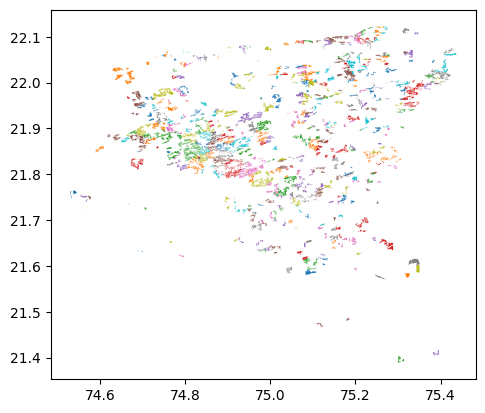

In [130]:
barwani_khasra_gdf_merged.plot(column="Village Name")

In [131]:
# Calculate original areas
barwani_khasra_gdf_merged["Original Area (ha)"] = (
    barwani_khasra_gdf_merged.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [132]:
# add % unusable area
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = (
    barwani_khasra_gdf_merged["Noiyat Unusable Area (ha)"]
    / barwani_khasra_gdf_merged["Original Area (ha)"]
    * 100
).round(2)

# set max to 100 and min to 0 for any weird values
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"] = barwani_khasra_gdf_merged[
    "Noiyat Unusable Area (%)"
].clip(0, 100)

<Axes: >

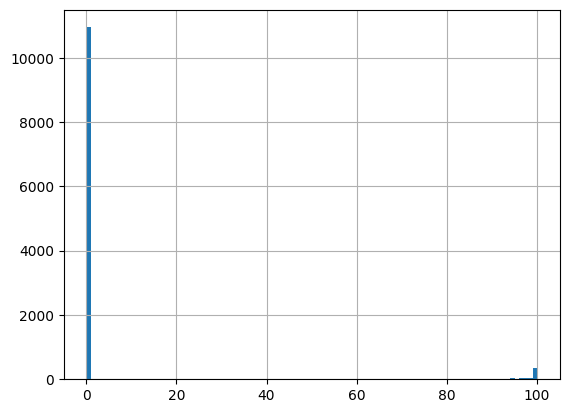

In [133]:
barwani_khasra_gdf_merged["Noiyat Unusable Area (%)"].hist(bins=100)

#### Cleanup and save

In [134]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_merged.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)

In [135]:
barwani_khasra_gdf_merged = barwani_khasra_gdf_merged[
    [
        "Khasra ID (Unique)",
        "Tehsil Code",
        "Village Name",
        "BHU Code",
        "Noiyat",
        "ROR KID",
        "Patch Name",
        "Khasra ID",
        "Original Area (ha)",
        "Noiyat Unusable Area (ha)",
        "Noiyat Unusable Area (%)",
        "geometry",
    ]
]

In [136]:
save_shapefiles(
    barwani_khasra_gdf_merged,
    PROCESSED_DATA_DIR / "Barwani" / "01 Processed Data" / "Cleaned Khasras",
    "barwani_cleaned_khasras",
    formats=["kml", "parquet"],
)

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '121/1, 121/8' of field barwani_cleaned_khasras.BHU Code parsed incompletely to real 121.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '122/1, 122/5, 122/4' of field barwani_cleaned_khasras.BHU Code parsed incompletely to real 122.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '124/5, 124/1, 124/4, 124/6' of field barwani_cleaned_khasras.BHU Code parsed incompletely to real 124.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning: Value '125/3, 125/1' of field barwani_cleaned_khasras.BHU Code parsed incompletely to real 125.
  ogr_write(
/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/pyogrio/raw.py:723: RuntimeWarning

### Betul

In [12]:
barwani_gdf = gpd.read_file(
    RAW_DATA_DIR / "solar_park_shapefiles" / "Betul Khasras" / "betul_khasras.kml",
    driver="KML",
)

In [13]:
# remove z-dimension
barwani_gdf.geometry = barwani_gdf.geometry.apply(
    lambda x: shapely.wkb.loads(shapely.wkb.dumps(x, output_dimension=2))
)
# break up multi-polygons
barwani_gdf = barwani_gdf.explode(column="geometry", ignore_index=True)
# drop any single points or lines
barwani_gdf = barwani_gdf[barwani_gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]

In [21]:
barwani_gdf = barwani_gdf[barwani_gdf["Name"] != ""]

<Axes: >

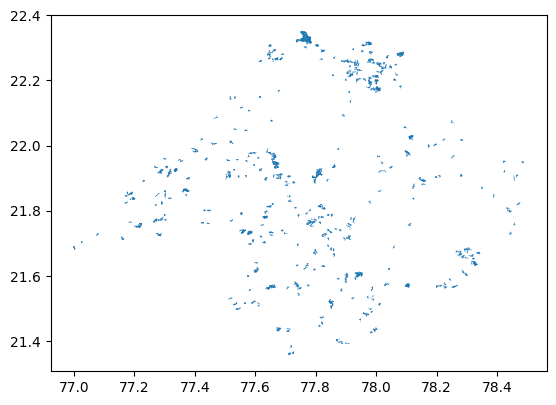

In [22]:
barwani_gdf.plot()

In [23]:
barwani_gdf

,Name,Description,geometry
1,BZU1,Unknown Area Type,"POLYGON ((77.71660 21.36455, 77.71662 21.36463..."
3,BZU2,Unknown Area Type,"POLYGON ((77.72777 21.36724, 77.72776 21.36735..."
5,BZU17,Unknown Area Type,"POLYGON ((77.71922 21.38606, 77.71909 21.38613..."
7,BZU32,Unknown Area Type,"POLYGON ((77.89885 21.39450, 77.89904 21.39485..."
9,BZU39,Unknown Area Type,"POLYGON ((77.88839 21.40047, 77.88739 21.40034..."
...,...,...,...
8391,1,Unknown Area Type,"POLYGON ((78.07646 22.28363, 78.07627 22.28386..."
8393,4,Unknown Area Type,"POLYGON ((78.07646 22.28363, 78.07627 22.28386..."
8395,23,Unknown Area Type,"POLYGON ((77.65108 22.30775, 77.65109 22.30780..."
8397,32,Unknown Area Type,"POLYGON ((77.65108 22.30775, 77.65109 22.30780..."


In [25]:
# no info in Description
barwani_gdf.drop(columns=["Description"], inplace=True)

KeyError: "['Description'] not found in axis"

#### Split up the Khasra vs Patch rows and overlay the patches to attach Patch Names to the Khasras

In [26]:
# the Name column has names like BZU1 for patches and others are khasras
# separate those who start with BZU
barwani_patches_gdf = barwani_gdf[barwani_gdf["Name"].str.startswith("BZU")]
barwani_patches_gdf["Name"] = barwani_patches_gdf["Name"].str.split(",").str[0]
barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)
barwani_patches_gdf

/Users/amiremami/.pyenv/versions/geospatial/lib/python3.12/site-packages/geopandas/geodataframe.py:1543: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_19388/3956756011.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barwani_patches_gdf.rename(columns={"Name": "Patch Name"}, inplace=True)


,Patch Name,geometry
1,BZU1,"POLYGON ((77.71660 21.36455, 77.71662 21.36463..."
3,BZU2,"POLYGON ((77.72777 21.36724, 77.72776 21.36735..."
5,BZU17,"POLYGON ((77.71922 21.38606, 77.71909 21.38613..."
7,BZU32,"POLYGON ((77.89885 21.39450, 77.89904 21.39485..."
9,BZU39,"POLYGON ((77.88839 21.40047, 77.88739 21.40034..."
...,...,...
661,BZU4075,"POLYGON ((77.96694 22.31918, 77.96692 22.31923..."
663,BZU4085,"POLYGON ((77.76705 22.32489, 77.76705 22.32490..."
665,BZU4086,"POLYGON ((77.76531 22.33093, 77.76535 22.33097..."
667,BZU4090,"POLYGON ((77.77090 22.34347, 77.77085 22.34377..."


In [28]:
# khasras
barwani_khasra_gdf = barwani_gdf[~barwani_gdf["Name"].str.startswith("BZU")]
barwani_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)
barwani_khasra_gdf

/var/folders/99/cwxq7sdx5d94rqxj57_crqbc0000gn/T/ipykernel_19388/3331575581.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  barwani_khasra_gdf.rename(columns={"Name": "Khasra ID"}, inplace=True)


,Khasra ID,geometry
671,125,"POLYGON ((77.71602 21.36030, 77.71595 21.36031..."
673,122,"POLYGON ((77.70925 21.36088, 77.70928 21.36082..."
675,128,"POLYGON ((77.71602 21.36030, 77.71602 21.36033..."
677,220/14,"POLYGON ((77.72324 21.36304, 77.72310 21.36305..."
679,128,"POLYGON ((77.72125 21.36211, 77.72132 21.36205..."
...,...,...
8391,1,"POLYGON ((78.07646 22.28363, 78.07627 22.28386..."
8393,4,"POLYGON ((78.07646 22.28363, 78.07627 22.28386..."
8395,23,"POLYGON ((77.65108 22.30775, 77.65109 22.30780..."
8397,32,"POLYGON ((77.65108 22.30775, 77.65109 22.30780..."


In [29]:
len(barwani_khasra_gdf) + len(barwani_patches_gdf) == len(barwani_gdf)

True

In [30]:
barwani_khasra_gdf = barwani_khasra_gdf.sjoin(
    barwani_patches_gdf, how="left", predicate="intersects"
).drop(columns=["index_right"])
# the sjoin might result in multiple rows for 1 khasra because multipe patches cover it. This causes the
# index to have duplicates. Only keep the first occurrence.
barwani_khasra_gdf = barwani_khasra_gdf[
    ~barwani_khasra_gdf.index.duplicated(keep="first")
]

In [31]:
barwani_khasra_gdf["Patch Name"].isnull().sum()

0

In [32]:
barwani_khasra_gdf

,Khasra ID,geometry,Patch Name
671,125,"POLYGON ((77.71602 21.36030, 77.71595 21.36031...",BZU1
673,122,"POLYGON ((77.70925 21.36088, 77.70928 21.36082...",BZU1
675,128,"POLYGON ((77.71602 21.36030, 77.71602 21.36033...",BZU1
677,220/14,"POLYGON ((77.72324 21.36304, 77.72310 21.36305...",BZU2
679,128,"POLYGON ((77.72125 21.36211, 77.72132 21.36205...",BZU2
...,...,...,...
8391,1,"POLYGON ((78.07646 22.28363, 78.07627 22.28386...",BZU4005
8393,4,"POLYGON ((78.07646 22.28363, 78.07627 22.28386...",BZU4005
8395,23,"POLYGON ((77.65108 22.30775, 77.65109 22.30780...",BZU4052
8397,32,"POLYGON ((77.65108 22.30775, 77.65109 22.30780...",BZU4052


#### Add unique ID column (Khasra ID is not unique across the dataset)

In [33]:
barwani_khasra_gdf["Khasra ID"].duplicated().sum()

3136

In [34]:
barwani_khasra_gdf["Khasra ID (Unique)"] = (
    barwani_khasra_gdf["Khasra ID"] + " (" + barwani_khasra_gdf["Patch Name"] + ")"
)

In [35]:
# without the "add_suffix_to_duplicates()" function, we can see the duplicates
dups = barwani_khasra_gdf[
    barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False)
].sort_values("Khasra ID (Unique)")
dups["number"] = range(len(dups))

duplicated_khasraID_list = dups["Khasra ID (Unique)"].unique()
print("Number of duplicated Khasra IDs:", len(duplicated_khasraID_list))

Number of duplicated Khasra IDs: 519


In [37]:
for khasra_id in tqdm(duplicated_khasraID_list[:100]):
    dups[dups["Khasra ID (Unique)"] == khasra_id].plot(
        column="number", alpha=0.5, legend=True
    )
    image_path = (
        PROCESSED_DATA_DIR
        / "Betul"
        / "01 Processed Data"
        / "Cleaned Khasras"
        / "duplicated khasra plots"
    )
    image_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(image_path / f"{khasra_id.replace('/', '_')}.png")
    plt.close()

  0%|          | 0/100 [00:00<?, ?it/s]

In [38]:
# looks like all duplicates are shards of a single real khasra - combine them here
barwani_khasra_gdf_dissolved = barwani_khasra_gdf.dissolve(
    by="Khasra ID (Unique)"
).reset_index()

# # ALTERNATIVE - if there are duplicates, add a suffix
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID"].astype(str)
# barwani_khasra_gdf["Khasra ID (Unique)"] = barwani_khasra_gdf["Khasra ID (Unique)"].where(
#     ~barwani_khasra_gdf["Khasra ID (Unique)"].duplicated(keep=False),
#     barwani_khasra_gdf["Khasra ID (Unique)"]
#     + "_part_"
#     + (barwani_khasra_gdf.groupby("Khasra ID (Unique)").cumcount() + 1).astype(str),
# )

In [39]:
barwani_khasra_gdf_dissolved["Khasra ID (Unique)"].duplicated().sum()

0

In [40]:
barwani_khasra_gdf_dissolved[
    barwani_khasra_gdf_dissolved.duplicated(
        subset=["Khasra ID", "Patch Name"], keep=False
    )
].sort_values(by=["Khasra ID"])

,Khasra ID (Unique),geometry,Khasra ID,Patch Name


In [45]:
barwani_khasra_gdf_dissolved = barwani_khasra_gdf_dissolved.sort_values(
    by=["Patch Name", "Khasra ID (Unique)"]
)
# Calculate original areas
barwani_khasra_gdf_dissolved["Original Area (ha)"] = (
    barwani_khasra_gdf_dissolved.to_crs(INDIA_PROJECTED_CRS).area / 10000
)

In [46]:
barwani_khasra_gdf_dissolved

,Khasra ID (Unique),geometry,Khasra ID,Patch Name,Original Area (ha)
195,121 (BZU1),"POLYGON ((77.70990 21.36144, 77.70994 21.36145...",121,BZU1,0.432744
200,122 (BZU1),"POLYGON ((77.70925 21.36088, 77.70928 21.36082...",122,BZU1,0.817783
213,124 (BZU1),"POLYGON ((77.71153 21.35842, 77.71158 21.35847...",124,BZU1,2.080606
215,125 (BZU1),"POLYGON ((77.71602 21.36030, 77.71595 21.36031...",125,BZU1,0.454494
230,128 (BZU1),"POLYGON ((77.71592 21.36032, 77.71583 21.36032...",128,BZU1,46.905774
...,...,...,...,...,...
812,23 (BZU959),"MULTIPOLYGON (((77.62905 21.70015, 77.62883 21...",23,BZU959,0.186204
92,109 (BZU982),"POLYGON ((77.59548 21.71178, 77.59645 21.71155...",109,BZU982,0.080666
2225,89 (BZU982),"POLYGON ((77.59329 21.70557, 77.59305 21.70558...",89,BZU982,7.851117
2261,92 (BZU982),"POLYGON ((77.59352 21.71108, 77.59345 21.71110...",92,BZU982,2.242117


In [43]:
barwani_khasra_gdf_dissolved

,Khasra ID (Unique),geometry,Khasra ID,Patch Name
195,121 (BZU1),"POLYGON ((77.70990 21.36144, 77.70994 21.36145...",121,BZU1
200,122 (BZU1),"POLYGON ((77.70925 21.36088, 77.70928 21.36082...",122,BZU1
213,124 (BZU1),"POLYGON ((77.71153 21.35842, 77.71158 21.35847...",124,BZU1
215,125 (BZU1),"POLYGON ((77.71602 21.36030, 77.71595 21.36031...",125,BZU1
230,128 (BZU1),"POLYGON ((77.71592 21.36032, 77.71583 21.36032...",128,BZU1
...,...,...,...,...
812,23 (BZU959),"MULTIPOLYGON (((77.62905 21.70015, 77.62883 21...",23,BZU959
92,109 (BZU982),"POLYGON ((77.59548 21.71178, 77.59645 21.71155...",109,BZU982
2225,89 (BZU982),"POLYGON ((77.59329 21.70557, 77.59305 21.70558...",89,BZU982
2261,92 (BZU982),"POLYGON ((77.59352 21.71108, 77.59345 21.71110...",92,BZU982


In [47]:
barwani_khasra_gdf_dissolved = barwani_khasra_gdf_dissolved[
    [
        "Khasra ID (Unique)",
        "Patch Name",
        "Khasra ID",
        "Original Area (ha)",
        "geometry",
    ]
]

In [49]:
save_shapefiles(
    barwani_khasra_gdf_dissolved,
    PROCESSED_DATA_DIR / "Betul" / "01 Processed Data" / "Cleaned Khasras",
    "betul_cleaned_khasras",
    formats=["kml", "parquet"],
)